

# Dependencies



In [26]:
# !pip -q install transformers sentence-transformers accelerate
# !pip -q install optuna
import optuna
import numpy as np
import pandas as pd
import textwrap, json, re
import os, zipfile, urllib.request
from dataclasses import dataclass
from typing import List, Dict, Any, Tuple
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sentence_transformers import SentenceTransformer
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [27]:
# ── FAST MODE ─────────────────────────────────────────────────────────────────────────
# Set FAST_MODE = True to run end-to-end quickly (Colab free-tier friendly).
# Trains with small d, few epochs/iters; evaluates on the first 300 eligible users.
# Set FAST_MODE = False to use the tuned hyperparameters (full quality).
FAST_MODE = False

# Fast-mode training parameters (from statement practical suggestions)
FAST_SGD_PARAMS = {'d': 20, 'lam_biases': 0.05, 'lam_factors': 0.05, 'eta': 0.01, 'epochs': 10}
FAST_ALS_PARAMS = {'d': 20, 'lam': 0.05, 'iters': 8}
FAST_N_EVAL     = 300   # user subset for evaluation
print(f'FAST_MODE = {FAST_MODE}')

FAST_MODE = False


# Data Preparation (MovieLens)

In [28]:
DATA_DIR = Path("../data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

ML100K_DIR = DATA_DIR / "ml-100k"
URL = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
zip_path = DATA_DIR / "ml-100k.zip"

if not ML100K_DIR.exists():
    if not zip_path.exists():
        print("Downloading MovieLens 100K...")
        urllib.request.urlretrieve(URL, zip_path.as_posix())
    else:
        print("Zip already downloaded:", zip_path)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_DIR)

print("Using data directory:", ML100K_DIR)
print("Top-level contents:", list(DATA_DIR.iterdir())[:5])

ratings_path = ML100K_DIR / "u.data"
# u.data format: user_id \t item_id \t rating \t timestamp
ratings = pd.read_csv(
    ratings_path,
    sep="\t",
    header=None,
    names=["user_id", "item_id", "rating", "timestamp"],
)

ratings.head(), ratings.shape

# Create contiguous indices for users and items
user_ids = ratings["user_id"].unique()
item_ids = ratings["item_id"].unique()

user2idx = {u: i for i, u in enumerate(sorted(user_ids))}
item2idx = {m: i for i, m in enumerate(sorted(item_ids))}

ratings["u"] = ratings["user_id"].map(user2idx).astype(int)
ratings["i"] = ratings["item_id"].map(item2idx).astype(int)

n_users = len(user2idx)
n_items = len(item2idx)

print("n_users:", n_users, "n_items:", n_items)
ratings[["u", "i", "rating"]].head()

rng = np.random.default_rng(42)
idx = np.arange(len(ratings))
rng.shuffle(idx)

split = int(0.8 * len(idx))
train_idx = idx[:split]
test_idx = idx[split:]

train = ratings.iloc[train_idx].reset_index(drop=True)
test = ratings.iloc[test_idx].reset_index(drop=True)

print("Train size:", len(train), "Test size:", len(test))

# Convert to numpy arrays for fast loops
train_u = train["u"].to_numpy(np.int64)
train_i = train["i"].to_numpy(np.int64)
train_r = train["rating"].to_numpy(np.float32)

test_u = test["u"].to_numpy(np.int64)
test_i = test["i"].to_numpy(np.int64)
test_r = test["rating"].to_numpy(np.float32)

train_u, val_u, train_i, val_i, train_r, val_r = train_test_split(
    train_u, train_i, train_r, test_size=0.2, random_state=42
)

Using data directory: ..\data\ml-100k
Top-level contents: [WindowsPath('../data/ml-100k'), WindowsPath('../data/README.md')]
n_users: 943 n_items: 1682
Train size: 80000 Test size: 20000


# Baseline global mean


In [29]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


mu = float(train_r.mean())
baseline_pred = np.full_like(test_r, mu, dtype=np.float32)

print("Global-mean baseline RMSE:", rmse(test_r, baseline_pred))

Global-mean baseline RMSE: 1.1331379413604736


# Build per-user and per-item interaction lists (useful for ALS)

In [30]:
def user_item_ratings(train_u, train_i, train_r):
    user_ratings = defaultdict(list)
    item_ratings = defaultdict(list)
    item_popularity = defaultdict(int)

    for u, i, r in zip(train_u, train_i, train_r):
        user_ratings[int(u)].append((int(i), float(r)))
        item_ratings[int(i)].append((int(u), float(r)))
        item_popularity[int(i)] += 1
    return user_ratings, item_ratings, item_popularity

# [MF-Methods] - Initialization

In [31]:
d = 20
lam = 0.05

rng = np.random.default_rng(0)
P = 0.1 * rng.standard_normal((n_users, d)).astype(np.float32)
Q = 0.1 * rng.standard_normal((n_items, d)).astype(np.float32)
bu = np.zeros(n_users, dtype=np.float32)
bi = np.zeros(n_items, dtype=np.float32)
user_ratings, item_ratings, item_popularity = user_item_ratings(
    train_u, train_i, train_r
)

# [MF-METHODS] - Save best state to use later

In [32]:
from pathlib import Path
import json
import numpy as np

def save_mf_state(path, *, P, Q, bu, bi, mu, d, model_name, lam=None, lam_factors=None, lam_biases=None, extra=None):
    if lam is None and lam_factors is None:
        raise ValueError("Provide either lam or lam_factors")
    _lam = lam if lam is not None else lam_factors
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        path,
        P=P,
        Q=Q,
        bu=bu,
        bi=bi,
        mu=np.array(mu, dtype=np.float32),
        d=np.array(d, dtype=np.int32),
        lam=np.array(_lam, dtype=np.float32),
    )

    meta = {
        "model_name": model_name,
        "d": int(d),
        "lam": float(_lam),
        "mu": float(mu),
    }
    if lam_factors is not None:
        meta["lam_factors"] = float(lam_factors)
    if lam_biases is not None:
        meta["lam_biases"] = float(lam_biases)
    if extra is not None:
        meta["extra"] = extra

    with open(path.with_suffix(".json"), "w") as f:
        json.dump(meta, f, indent=2)


def load_mf_state(path):
    path = Path(path)
    data = np.load(path, allow_pickle=False)
    with open(path.with_suffix(".json"), "r") as f:
        meta = json.load(f)

    return {
        "P": data["P"],
        "Q": data["Q"],
        "bu": data["bu"],
        "bi": data["bi"],
        "mu": float(data["mu"]),
        "d": int(data["d"]),
        "lam": float(data["lam"]),
        "meta": meta,
    }

# [MF-Methods] - Helpers

In [33]:
def predict(u, i, mu, bu, bi, P, Q):
    return mu + bu[u] + bi[i] + float(P[u] @ Q[i])


def batch_predict(u_arr, i_arr, mu, bu, bi, P, Q):
    out = np.empty(len(u_arr), dtype=np.float32)
    for k, (u, i) in enumerate(zip(u_arr, i_arr)):
        out[k] = mu + bu[u] + bi[i] + float(P[u] @ Q[i])
    return out


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))


def mf_predict(u_arr, i_arr, mu, bu, bi, P, Q):
    return mu + bu[u_arr] + bi[i_arr] + np.einsum("nd,nd->n", P[u_arr], Q[i_arr])


def mf_score(u, i, mu, bu, bi, P, Q):
    return float(mu + bu[u] + bi[i] + P[u] @ Q[i])

# [MF-Methods] - SGD (Implementation)


In [34]:
def train_sgd_mf(
    train_u, train_i, train_r,
    val_u, val_i, val_r,
    n_users, n_items,
    d=20, lam_factors=0.05, lam_biases=0.05, eta=0.01, epochs=20,
    seed=0, save_path=None
):
    rng = np.random.default_rng(seed)
    P = (0.1 * rng.standard_normal((n_users, d))).astype(np.float32)
    Q = (0.1 * rng.standard_normal((n_items, d))).astype(np.float32)
    bu = np.zeros(n_users, dtype=np.float32)
    bi = np.zeros(n_items, dtype=np.float32)

    mu = float(train_r.mean())

    best = {
        "val_rmse": float("inf"),
        "P": None, "Q": None, "bu": None, "bi": None,
        "epoch": None,
    }

    train_curve, val_curve = [], []

    for ep in range(1, epochs + 1):
        order = rng.permutation(len(train_u))
        for k in order:
            u, i, r = int(train_u[k]), int(train_i[k]), float(train_r[k])
            pred = mu + bu[u] + bi[i] + float(P[u] @ Q[i])
            err = r - pred

            # keep old Pu if you want a more "standard" SGD update
            pu_old = P[u].copy()

            bu[u] += eta * (err - lam_biases * bu[u])
            bi[i] += eta * (err - lam_biases * bi[i])
            P[u] += eta * (err * Q[i] - lam_factors * P[u])
            Q[i] += eta * (err * pu_old - lam_factors * Q[i])

        tr_rmse = rmse(train_r, mf_predict(train_u, train_i, mu, bu, bi, P, Q))
        va_rmse = rmse(val_r, mf_predict(val_u, val_i, mu, bu, bi, P, Q))
        train_curve.append(tr_rmse)
        val_curve.append(va_rmse)

        if va_rmse < best["val_rmse"]:
            best["val_rmse"] = va_rmse
            best["P"] = P.copy()
            best["Q"] = Q.copy()
            best["bu"] = bu.copy()
            best["bi"] = bi.copy()
            best["epoch"] = ep

        print(f"Epoch {ep:02d} | train RMSE={tr_rmse:.4f} | val RMSE={va_rmse:.4f}")

    best_state = {
        "P": best["P"],
        "Q": best["Q"],
        "bu": best["bu"],
        "bi": best["bi"],
        "mu": mu,
        "d": d,
        "lam_biases": lam_biases,
        "lam_factors": lam_factors,
        "best_epoch": best["epoch"],
        "val_rmse": best["val_rmse"],
        "train_curve": train_curve,
        "val_curve": val_curve,
    }

    if save_path is not None:
        save_mf_state(
            save_path,
            P=best_state["P"],
            Q=best_state["Q"],
            bu=best_state["bu"],
            bi=best_state["bi"],
            mu=best_state["mu"],
            d=best_state["d"],
            lam_factors=best_state["lam_factors"],
            lam_biases=best_state["lam_biases"],
            model_name="sgd_mf",
            extra={"best_epoch": best_state["best_epoch"]}
        )

    return best_state

# [MF-Methods] - SGD (tuning)

In [35]:
def tune_sgd(n_trials=50):
    
    def objective(trial):
        d = trial.suggest_int("d", 20, 120)
        lam_biases = trial.suggest_float("lam_biases", 1e-4, 0.05, log=True)
        lam_factors = trial.suggest_float("lam_factors", 0.01, 0.3, log=True)
        eta = trial.suggest_float("eta", 0.002, 0.03, log=True)
        epochs = trial.suggest_int("epochs", 10, 80)
        state = train_sgd_mf(
            train_u,
            train_i,
            train_r,
            val_u,
            val_i,
            val_r,
            n_users,
            n_items,
            d,
            lam_factors,
            lam_biases,
            eta,
            epochs,
        )
        val_rmse = min(state["val_curve"])
        return val_rmse
    
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    print("\nBest parameters:")
    print(study.best_params)

    print("\nBest validation RMSE:")
    print(study.best_value)

    return study.best_params

# [MF-Methods] - ALS (implementation)

In [36]:
def train_als_mf(
    train_u, train_i, train_r,
    val_u, val_i, val_r,
    n_users, n_items,
    user_ratings, item_ratings,
    d=20, lam=0.05, iters=5,
    seed=0, save_path=None
):
    rng = np.random.default_rng(seed)
    P = (0.1 * rng.standard_normal((n_users, d))).astype(np.float32)
    Q = (0.1 * rng.standard_normal((n_items, d))).astype(np.float32)
    bu = np.zeros(n_users, dtype=np.float32)
    bi = np.zeros(n_items, dtype=np.float32)

    mu = float(train_r.mean())
    I = np.eye(d, dtype=np.float32)

    best = {
        "val_rmse": float("inf"),
        "P": None, "Q": None, "bu": None, "bi": None,
        "iter": None,
    }

    train_curve, val_curve = [], []

    for it in range(1, iters + 1):
        # update user factors
        for u in range(n_users):
            items = user_ratings.get(u, [])
            if not items:
                continue
            A = lam * I
            b = np.zeros(d, dtype=np.float32)
            for i, r in items:
                qi = Q[i]
                A += np.outer(qi, qi)
                b += (r - mu - bu[u] - bi[i]) * qi
            P[u] = np.linalg.solve(A, b)

        # update item factors
        for i in range(n_items):
            users = item_ratings.get(i, [])
            if not users:
                continue
            A = lam * I
            b = np.zeros(d, dtype=np.float32)
            for u, r in users:
                pu = P[u]
                A += np.outer(pu, pu)
                b += (r - mu - bu[u] - bi[i]) * pu
            Q[i] = np.linalg.solve(A, b)

        # update biases
        for u in range(n_users):
            items = user_ratings.get(u, [])
            if not items:
                continue
            num = 0.0
            for i, r in items:
                num += r - mu - bi[i] - P[u] @ Q[i]
            bu[u] = num / (lam + len(items))

        for i in range(n_items):
            users = item_ratings.get(i, [])
            if not users:
                continue
            num = 0.0
            for u, r in users:
                num += r - mu - bu[u] - P[u] @ Q[i]
            bi[i] = num / (lam + len(users))

        tr_rmse = rmse(train_r, batch_predict(train_u, train_i, mu, bu, bi, P, Q))
        va_rmse = rmse(val_r, batch_predict(val_u, val_i, mu, bu, bi, P, Q))
        train_curve.append(tr_rmse)
        val_curve.append(va_rmse)

        if va_rmse < best["val_rmse"]:
            best["val_rmse"] = va_rmse
            best["P"] = P.copy()
            best["Q"] = Q.copy()
            best["bu"] = bu.copy()
            best["bi"] = bi.copy()
            best["iter"] = it

        print(f"ALS iter {it:02d} | train RMSE={tr_rmse:.4f} | val RMSE={va_rmse:.4f}")

    best_state = {
        "P": best["P"],
        "Q": best["Q"],
        "bu": best["bu"],
        "bi": best["bi"],
        "mu": mu,
        "d": d,
        "lam": lam,
        "best_iter": best["iter"],
        "val_rmse": best["val_rmse"],
        "train_curve": train_curve,
        "val_curve": val_curve,
    }

    if save_path is not None:
        save_mf_state(
            save_path,
            P=best_state["P"],
            Q=best_state["Q"],
            bu=best_state["bu"],
            bi=best_state["bi"],
            mu=best_state["mu"],
            d=best_state["d"],
            lam=best_state["lam"],
            model_name="als_mf",
            extra={"best_iter": best_state["best_iter"]}
        )

    return best_state

# [MF-Methods] - ALS (tuning)

In [37]:
def tune_als(n_trials=40):

    def objective(trial):
        d = trial.suggest_int("d", 10, 150)
        lam = trial.suggest_float(
            "lam",
            1e-3,
            10.0,
            log=True
        )
        iters = trial.suggest_int("iters", 2, 25)
        state = train_als_mf(
            train_u,
            train_i,
            train_r,
            val_u,
            val_i,
            val_r,
            n_users,
            n_items,
            user_ratings,
            item_ratings,
            d,
            lam,
            iters
        )
        val_rmse = min(state["val_curve"])
        return val_rmse


    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    print("\nBest ALS params:")
    print(study.best_params)

    print("\nBest validation RMSE:")
    print(study.best_value)

    return study.best_params

# [MF-Methods] - train


In [38]:
# Best params found by Optuna (used when FAST_MODE = False)
sgd_best_params = {
    'd': 81,
    'lam_biases': 0.0005274432500432459,
    'lam_factors': 0.11381526595226511,
    'eta': 0.011638537448331186,
    'epochs': 75
}
als_best_params = {
    'd': 131,
    'lam': 9.71633075356387,
    'iters': 15
}

sgd_params = FAST_SGD_PARAMS if FAST_MODE else sgd_best_params
als_params = FAST_ALS_PARAMS if FAST_MODE else als_best_params

print(f'SGD params: {sgd_params}')
print(f'ALS params: {als_params}')

sgd_state = train_sgd_mf(
    train_u, train_i, train_r,
    val_u, val_i, val_r,
    n_users, n_items,
    d=sgd_params['d'], lam_factors=sgd_params['lam_factors'],
    lam_biases=sgd_params['lam_biases'], eta=sgd_params['eta'],
    epochs=sgd_params['epochs'],
    save_path='artifacts/sgd_mf_best'
)

als_state = train_als_mf(
    train_u, train_i, train_r,
    val_u, val_i, val_r,
    n_users, n_items,
    user_ratings, item_ratings,
    d=als_params['d'], lam=als_params['lam'], iters=als_params['iters'],
    save_path='artifacts/als_mf_best'
)

print(f"SGD val RMSE: {sgd_state['val_rmse']:.4f}")
print(f"ALS val RMSE: {als_state['val_rmse']:.4f}")

SGD params: {'d': 81, 'lam_biases': 0.0005274432500432459, 'lam_factors': 0.11381526595226511, 'eta': 0.011638537448331186, 'epochs': 75}
ALS params: {'d': 131, 'lam': 9.71633075356387, 'iters': 15}
Epoch 01 | train RMSE=0.9513 | val RMSE=0.9868
Epoch 02 | train RMSE=0.9186 | val RMSE=0.9672
Epoch 03 | train RMSE=0.9028 | val RMSE=0.9593
Epoch 04 | train RMSE=0.8929 | val RMSE=0.9554
Epoch 05 | train RMSE=0.8859 | val RMSE=0.9527
Epoch 06 | train RMSE=0.8802 | val RMSE=0.9512
Epoch 07 | train RMSE=0.8753 | val RMSE=0.9500
Epoch 08 | train RMSE=0.8704 | val RMSE=0.9493
Epoch 09 | train RMSE=0.8657 | val RMSE=0.9471
Epoch 10 | train RMSE=0.8608 | val RMSE=0.9463
Epoch 11 | train RMSE=0.8556 | val RMSE=0.9453
Epoch 12 | train RMSE=0.8500 | val RMSE=0.9447
Epoch 13 | train RMSE=0.8441 | val RMSE=0.9431
Epoch 14 | train RMSE=0.8379 | val RMSE=0.9414
Epoch 15 | train RMSE=0.8316 | val RMSE=0.9400
Epoch 16 | train RMSE=0.8246 | val RMSE=0.9389
Epoch 17 | train RMSE=0.8179 | val RMSE=0.9377
Ep

# [LTR] - Preference pairs


In [39]:
MAX_PAIRS_PER_USER = 50

preference_pairs = []  # list of (u, i_pos, i_neg)

for u, items in user_ratings.items():
    positives = [i for i, r in items if r >= 4]
    negatives = [i for i, r in items if r <= 2]
    if not positives or not negatives:
        continue

    # Shuffle for random sampling
    rng = np.random.default_rng(u)
    rng.shuffle(positives)
    rng.shuffle(negatives)

    count = 0
    for i_pos in positives:
        for i_neg in negatives:
            if count >= MAX_PAIRS_PER_USER:
                break
            preference_pairs.append((u, i_pos, i_neg))
            count += 1
        if count >= MAX_PAIRS_PER_USER:
            break

preference_pairs = np.array(preference_pairs, dtype=np.int64)  # shape (N, 3)
print(f"Total preference pairs: {len(preference_pairs)}")

Total preference pairs: 37358


# [LTR] - Feature extraction

In [40]:
max_pop = max(item_popularity.values())
mf = load_mf_state("artifacts/sgd_mf_best.npz")
P_mf, Q_mf, bu_mf, bi_mf, mu = mf["P"], mf["Q"], mf["bu"], mf["bi"], mf["mu"]


def get_features(u, i, mu, bu, bi, P, Q):
    """Feature vector f(u,i) = [s_MF, b_u, b_i, pop(i), 1] for the linear ranker."""
    mf_s = float(mu + bu[u] + bi[i] + P[u] @ Q[i])
    pop  = np.log1p(item_popularity.get(i, 0)) / np.log1p(max_pop)
    return np.array([mf_s, float(bu[u]), float(bi[i]), pop, 1.0], dtype=np.float64)


N_FEATURES = 5  # [s_MF, b_u, b_i, pop, bias]

# Pre-compute features for all pairs
F_pos = np.zeros((len(preference_pairs), N_FEATURES))
F_neg = np.zeros((len(preference_pairs), N_FEATURES))
for k, (u, i_pos, i_neg) in enumerate(preference_pairs):
    F_pos[k] = get_features(u, i_pos, mu, bu_mf, bi_mf, P_mf, Q_mf)
    F_neg[k] = get_features(u, i_neg, mu, bu_mf, bi_mf, P_mf, Q_mf)

delta_F = F_pos - F_neg  # shape (N, 5)
print(f"delta_F shape: {delta_F.shape}")
print("Features: [s_MF, b_u, b_i, pop, bias]")

delta_F shape: (37358, 5)
Features: [s_MF, b_u, b_i, pop, bias]


# [LTR] - Pairwise Model

In [41]:
# Linear ranker - gradient descent on pairwise loss
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))


lam_phi = 1e-3
eta_phi = 0.05
n_epochs_ltr = 100

phi = np.zeros(N_FEATURES)  # initialise at zero
loss_history = []

for ep in range(1, n_epochs_ltr + 1):
    # Vectorised update over all pairs
    scores = delta_F @ phi  # shape (N,)
    sigma = sigmoid(scores)  # Pr(i+ > i-)

    # Gradient: d/dphi [ -log sigma(phi^T delta_f) ] = (sigma - 1) * delta_f
    grad = ((sigma - 1.0)[:, None] * delta_F).mean(axis=0) + lam_phi * phi
    phi -= eta_phi * grad

    loss = -np.log(sigma + 1e-10).mean() + 0.5 * lam_phi * np.dot(phi, phi)
    loss_history.append(loss)

    if ep % 20 == 0:
        print(f"Epoch {ep:3d} | loss={loss:.4f} | phi={phi}")

print(f"\nLearned weights phi: {phi}")
print("Feature names:       [mf_score, user_bias, item_bias, log_pop]")

Epoch  20 | loss=0.4257 | phi=[0.48559434 0.         0.18734543 0.02416756 0.        ]
Epoch  40 | loss=0.3192 | phi=[0.78976675 0.         0.28358055 0.03537465 0.        ]
Epoch  60 | loss=0.2655 | phi=[1.01103369 0.         0.34059503 0.04117926 0.        ]
Epoch  80 | loss=0.2328 | phi=[1.1863413  0.         0.37707975 0.04424145 0.        ]
Epoch 100 | loss=0.2105 | phi=[1.33245771 0.         0.40119543 0.04569729 0.        ]

Learned weights phi: [1.33245771 0.         0.40119543 0.04569729 0.        ]
Feature names:       [mf_score, user_bias, item_bias, log_pop]


# [LTR] - Evaluation: NDCG@K and Recall@K

In [42]:
# Items each user rated in train â€” exclude when ranking
user_train_items = {u: set(i for i, _ in items) for u, items in user_ratings.items()}

# Ground-truth: relevant test items (rating >= 4) per user
user_test_relevant = defaultdict(set)
for u, i, r in zip(test_u, test_i, test_r):
    if r >= 4:
        user_test_relevant[int(u)].add(int(i))

eval_users = [u for u, items in user_test_relevant.items() if len(items) > 0]
print(f"Users with >= 1 relevant test item: {len(eval_users)}")

Users with >= 1 relevant test item: 922


In [43]:
def dcg_at_k(relevances, K):
    return sum(rel / np.log2(rank + 2) for rank, rel in enumerate(relevances[:K]))


def ndcg_at_k(ranked_items, relevant_set, K):
    rels = [1 if int(item) in relevant_set else 0 for item in list(ranked_items)[:K]]
    dcg = dcg_at_k(rels, K)
    n_rel = min(len(relevant_set), K)
    idcg = dcg_at_k([1] * n_rel + [0] * (K - n_rel), K)
    return dcg / idcg if idcg > 0 else 0.0


def recall_at_k(ranked_items, relevant_set, K):
    hits = sum(1 for item in list(ranked_items)[:K] if int(item) in relevant_set)
    return hits / len(relevant_set) if relevant_set else 0.0


def get_top_k(u, scorer, K, exclude_train=True):
    exclude = user_train_items.get(u, set()) if exclude_train else set()
    scores = np.array(
        [scorer(u, i) if i not in exclude else -np.inf for i in range(n_items)]
    )
    return np.argsort(-scores)[:K]


def mf_scorer(u, i):
    return mf_score(u, i, mu, bu_mf, bi_mf, P_mf, Q_mf)


def ranker_score(u, i):
    return float(phi @ get_features(u, i, mu, bu_mf, bi_mf, P_mf, Q_mf))

In [44]:
# E1: Baseline Comparison — Popularity vs MF-SGD vs MF-ALS vs Pairwise LTR

# Popularity-based ranker
def pop_scorer(u, i):
    """Rank by global train interaction count."""
    return float(item_popularity.get(i, 0))


# Load ALS model for comparison
als = load_mf_state("artifacts/als_mf_best.npz")
P_als, Q_als, bu_als, bi_als, mu_als = als["P"], als["Q"], als["bu"], als["bi"], als["mu"]

def als_scorer(u, i):
    return mf_score(u, i, mu_als, bu_als, bi_als, P_als, Q_als)


n_eval = min(FAST_N_EVAL if FAST_MODE else 300, len(eval_users))
eval_subset = eval_users[:n_eval]
print(f"Evaluating on {n_eval} users")

results = {}
for name, scorer in [
    ("Popularity",    pop_scorer),
    ("MF-SGD",        mf_scorer),
    ("MF-ALS",        als_scorer),
    ("Pairwise LTR",  ranker_score),
]:
    ndcg10, rec10 = [], []
    for u in eval_subset:
        rel   = user_test_relevant[u]
        top10 = get_top_k(u, scorer, K=10)
        ndcg10.append(ndcg_at_k(top10, rel, 10))
        rec10.append(recall_at_k(top10, rel, 10))
    results[name] = {
        "Recall@10": np.mean(rec10),
        "NDCG@10":   np.mean(ndcg10),
    }

print("\n=== E1: Baseline Comparison ===")
print(pd.DataFrame(results).T.to_string(float_format="{:.4f}".format))

Evaluating on 300 users

=== E1: Baseline Comparison ===
              Recall@10  NDCG@10
Popularity       0.0917   0.1768
MF-SGD           0.0453   0.0799
MF-ALS           0.0816   0.1725
Pairwise LTR     0.0457   0.0823


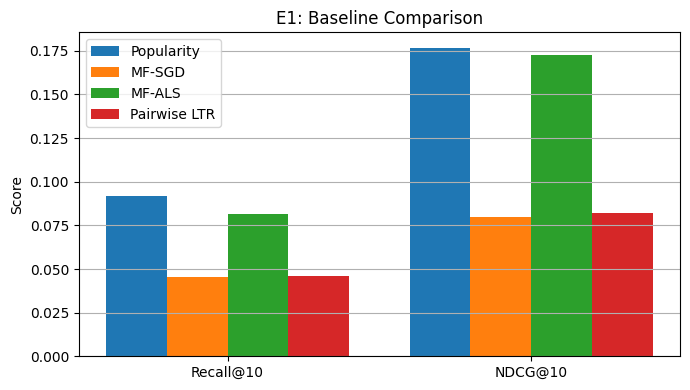

In [45]:
metrics = ["Recall@10", "NDCG@10"]
n_rankers = len(results)
width = 0.8 / n_rankers
x = np.arange(len(metrics))

fig, ax = plt.subplots(figsize=(7, 4))
for k, (name, vals) in enumerate(results.items()):
    ax.bar(x + (k - n_rankers / 2 + 0.5) * width,
           [vals[m] for m in metrics], width, label=name)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("E1: Baseline Comparison")
ax.legend()
ax.grid(axis="y")
plt.tight_layout()
plt.show()

# [LTR] - MMR Diversity Reranking

In [46]:
# Load genre one-hot vectors from u.item (19 genre columns, indices 5-23)
genre_matrix = np.zeros((n_items, 19), dtype=np.float32)
with open(ML100K_DIR / "u.item", encoding="latin-1") as f:
    for line in f:
        parts = line.strip().split("|")
        raw_id = int(parts[0])
        if raw_id in item2idx:
            idx = item2idx[raw_id]
            genre_matrix[idx] = [float(parts[5 + g]) for g in range(19)]

# L2-normalise so cosine similarity = dot product
norms = np.linalg.norm(genre_matrix, axis=1, keepdims=True)
genre_norm = genre_matrix / (norms + 1e-10)   # shape (n_items, 19)
print(f"Genre matrix: {genre_norm.shape}, non-zero rows: {(norms > 0).sum()}")

Genre matrix: (1682, 19), non-zero rows: 1682


In [47]:
def item_sim(i, j):
    """Cosine similarity between genre vectors (as required by statement)."""
    return float(genre_norm[i] @ genre_norm[j])


def mmr_rerank(candidate_items, candidate_scores, K, alpha):
    """
    Maximal Marginal Relevance reranking.
    candidate_scores: normalised to [0,1].
    alpha=0 -> pure relevance; alpha=1 -> pure diversity.
    """
    selected = []
    remaining = list(zip(candidate_items, candidate_scores))
    while len(selected) < K and remaining:
        if not selected:
            best = int(np.argmax([s for _, s in remaining]))
        else:
            mmr_scores = [
                (1 - alpha) * s
                - alpha * max(item_sim(c, s_item) for s_item in selected)
                for c, s in remaining
            ]
            best = int(np.argmax(mmr_scores))
        selected.append(remaining[best][0])
        remaining.pop(best)
    return selected


def diversity_at_k(ranked_items, K):
    """Average pairwise cosine distance computed from genre vectors."""
    items = list(ranked_items)[:K]
    if len(items) < 2:
        return 0.0
    sims = [
        item_sim(items[a], items[b])
        for a in range(len(items))
        for b in range(a + 1, len(items))
    ]
    return 1.0 - float(np.mean(sims))


print("MMR helpers defined (genre-vector cosine similarity).")

MMR helpers defined (genre-vector cosine similarity).


In [48]:
# E2: MMR Relevance–Diversity Tradeoff
M_MMR = 80   # candidate pool size for MMR
K_MMR = 10
alphas = [0, 0.1, 0.4, 0.7, 1]

mmr_ndcg = {a: [] for a in alphas}
mmr_div  = {a: [] for a in alphas}

n_mmr_eval = min(200, len(eval_users))
for u in eval_users[:n_mmr_eval]:
    rel     = user_test_relevant[u]
    exclude = user_train_items.get(u, set())
    # Score with MF-SGD baseline
    all_scores = np.array(
        [mf_scorer(u, i) if i not in exclude else -np.inf for i in range(n_items)]
    )
    top_m = np.argsort(-all_scores)[:M_MMR]
    raw_s = all_scores[top_m]
    norm_s = (raw_s - raw_s.min()) / (raw_s.max() - raw_s.min() + 1e-10)
    for alpha in alphas:
        ranked = mmr_rerank(top_m.tolist(), norm_s.tolist(), K_MMR, alpha)
        mmr_ndcg[alpha].append(ndcg_at_k(ranked, rel, K_MMR))
        mmr_div[alpha].append(diversity_at_k(ranked, K_MMR))

print("alpha | NDCG@10 | Diversity@10")
print("------+---------+-------------")
for a in alphas:
    print(f"{a:.1f}   | {np.mean(mmr_ndcg[a]):.4f}  | {np.mean(mmr_div[a]):.4f}")

alpha | NDCG@10 | Diversity@10
------+---------+-------------
0.0   | 0.0817  | 0.7370
0.1   | 0.0804  | 0.7964
0.4   | 0.0688  | 0.9312
0.7   | 0.0667  | 0.9615
1.0   | 0.0667  | 0.9695


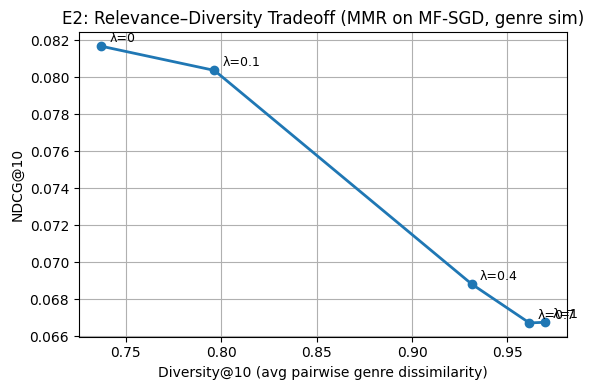

In [49]:
# E2 Plot: NDCG@10 vs Diversity@10 for alpha in {0.1, 0.4, 0.7}
div_vals  = [np.mean(mmr_div[a])  for a in alphas]
ndcg_vals = [np.mean(mmr_ndcg[a]) for a in alphas]

plt.figure(figsize=(6, 4))
plt.plot(div_vals, ndcg_vals, marker="o", linewidth=2)
for a, d, n in zip(alphas, div_vals, ndcg_vals):
    plt.annotate(f"λ={a}", (d, n), textcoords="offset points", xytext=(6, 3), fontsize=9)
plt.xlabel("Diversity@10 (avg pairwise genre dissimilarity)")
plt.ylabel("NDCG@10")
plt.title("E2: Relevance–Diversity Tradeoff (MMR on MF-SGD, genre sim)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Ablation Study

- **Ablation A** – effect of removing MMR reranking (alpha=0 vs alpha=0.3)
- **Ablation B** – effect of removing the popularity feature from LTR

In [50]:
# ── Ablation A: effect of MMR ────────────────────────────────────────────
# Compare Pairwise LTR without MMR (straight top-K) vs with MMR (lambda=0.4).

def eval_with_mmr(alpha, scorer, eval_users_subset, K=10, M=80):
    """Evaluate a scorer with MMR reranking at a given alpha."""
    ndcg_l, rec_l, div_l = [], [], []
    for u in eval_users_subset:
        rel     = user_test_relevant[u]
        exclude = user_train_items.get(u, set())
        all_s   = np.array(
            [scorer(u, i) if i not in exclude else -np.inf for i in range(n_items)]
        )
        top_m   = np.argsort(-all_s)[:M]
        raw_s   = all_s[top_m]
        norm_s  = (raw_s - raw_s.min()) / (raw_s.max() - raw_s.min() + 1e-10)
        if alpha == 0.0:
            ranked = top_m[:K].tolist()
        else:
            ranked = mmr_rerank(top_m.tolist(), norm_s.tolist(), K, alpha)
        ndcg_l.append(ndcg_at_k(ranked, rel, K))
        rec_l.append(recall_at_k(ranked, rel, K))
        div_l.append(diversity_at_k(ranked, K))
    return np.mean(ndcg_l), np.mean(rec_l), np.mean(div_l)


print("=== Ablation A: Effect of MMR (on Pairwise LTR) ===")
print(f"{'':25s} {'NDCG@10':>10} {'Recall@10':>10} {'Diversity@10':>13}")
for alpha_val, label in [(0.0, 'LTR (no MMR)'), (0.4, 'LTR + MMR (λ=0.4)')]:
    nd, rc, dv = eval_with_mmr(alpha_val, ranker_score, eval_subset)
    print(f"{label:25s} {nd:10.4f} {rc:10.4f} {dv:13.4f}")


# ── Ablation B: effect of popularity feature ────────────────────────────────
# Retrain phi without the popularity feature (use only first 4 features:
# s_MF, b_u, b_i, bias; drop pop at index 3).
keep_idx     = [0, 1, 2, 4]          # indices of features to keep
delta_F_nopop = delta_F[:, keep_idx]  # shape (N, 4)

phi_nopop    = np.zeros(4)
lam_np, eta_np = 1e-3, 0.05
for ep in range(1, 101):
    s_np  = delta_F_nopop @ phi_nopop
    sig   = 1.0 / (1.0 + np.exp(-np.clip(s_np, -30, 30)))
    grad  = ((sig - 1.0)[:, None] * delta_F_nopop).mean(axis=0) + lam_np * phi_nopop
    phi_nopop -= eta_np * grad


def ranker_nopop(u, i):
    f = get_features(u, i, mu, bu_mf, bi_mf, P_mf, Q_mf)
    return float(phi_nopop @ f[keep_idx])


print("\n=== Ablation B: Effect of Popularity Feature ===")
ablation_b = {}
for name, scorer in [
    ('LTR (full, 5 features)',      ranker_score),
    ('LTR (no pop, 4 features)',    ranker_nopop),
]:
    nd10, rc10 = [], []
    for u in eval_subset:
        rel   = user_test_relevant[u]
        top10 = get_top_k(u, scorer, K=10)
        nd10.append(ndcg_at_k(top10, rel, 10))
        rc10.append(recall_at_k(top10, rel, 10))
    ablation_b[name] = {'NDCG@10': np.mean(nd10), 'Recall@10': np.mean(rc10)}

print(pd.DataFrame(ablation_b).T.to_string(float_format='{:.4f}'.format))
print(f"\nFull phi (5 feats):   {phi}")
print(f"No-pop phi (4 feats): {phi_nopop}  (s_MF, b_u, b_i, bias)")

=== Ablation A: Effect of MMR (on Pairwise LTR) ===
                             NDCG@10  Recall@10  Diversity@10
LTR (no MMR)                  0.0823     0.0457        0.7539
LTR + MMR (λ=0.4)             0.0682     0.0375        0.9359

=== Ablation B: Effect of Popularity Feature ===
                          NDCG@10  Recall@10
LTR (full, 5 features)     0.0823     0.0457
LTR (no pop, 4 features)   0.0785     0.0441

Full phi (5 feats):   [1.33245771 0.         0.40119543 0.04569729 0.        ]
No-pop phi (4 feats): [1.33362896 0.         0.4025163  0.        ]  (s_MF, b_u, b_i, bias)


# Main Pipeline
> Candidate Generation → Ranking → MMR → User Feedback → EMA Update

Full interactive recommendation loop:
1. **Candidate generation** — all items the user has *not* seen in train
2. **Ranking** — score candidates with MF or LTR
3. **Reranking** — MMR on top-M candidates → diverse top-K list
4. **User feedback** — user picks one item (simulated via test ratings)
5. **State update** — EMA on user embedding: $p_u \leftarrow (1-\beta)\,p_u + \beta\,q_{i^*}$

In [51]:
# Load item titles for readable output
items_path = ML100K_DIR / "u.item"
item_titles = {}
with open(items_path, encoding="latin-1") as f:
    for line in f:
        parts = line.strip().split("|")
        if len(parts) >= 2:
            raw_id = int(parts[0])
            if raw_id in item2idx:
                item_titles[item2idx[raw_id]] = parts[1]
print(f"Loaded {len(item_titles)} item titles")

Loaded 1682 item titles


In [52]:
def generate_candidates(u):
    """Stage 1: all items the user has not rated in train."""
    seen = user_train_items.get(u, set())
    return [i for i in range(n_items) if i not in seen]


def rank_candidates(u, candidates, scorer):
    """Stage 2: score and sort candidates."""
    scores = np.array([scorer(u, i) for i in candidates])
    order  = np.argsort(-scores)
    return [candidates[k] for k in order], scores[order]


def rerank_mmr(items, scores, K, alpha):
    """Stage 3: MMR reranking on top-M=80 candidates -> top-K diverse list."""
    M       = min(80, len(items))
    top_items  = items[:M]
    top_scores = scores[:M]
    s_min, s_max = top_scores.min(), top_scores.max()
    norm = (top_scores - s_min) / (s_max - s_min + 1e-10)
    return mmr_rerank(top_items, norm.tolist(), K, alpha)


def simulate_feedback(u, ranked_items):
    """Stage 4: simulated user pick — choose highest-rated item in top-10.
    Prefers items with known test ratings; falls back to random if none.
    """
    user_test = {i: r for i, r in zip(test_i[test_u == u], test_r[test_u == u])}
    top_n = min(10, len(ranked_items))
    top_slice = ranked_items[:top_n]
    # Pick highest-rated item among those with known test rating
    rated = [(i, user_test[i]) for i in top_slice if i in user_test]
    if rated:
        chosen_item = max(rated, key=lambda x: x[1])[0]
    else:
        chosen_item = int(rng.choice(top_slice))
    rating = user_test.get(chosen_item, None)
    return chosen_item, rating


def update_user_state(u, i_selected, P, Q, beta=0.1):
    """Stage 5: EMA update of user embedding: p_u <- (1-beta)*p_u + beta*q_i."""
    P[u] = (1 - beta) * P[u] + beta * Q[i_selected]


# Normalise EMA update (optional variant used in statement formula)
def update_user_state_normed(u, i_selected, P, Q, beta=0.1):
    """Normalised EMA: p_u <- [(1-beta)*p_u + beta*q_i] / ||(1-beta)*p_u + beta*q_i||."""
    raw = (1 - beta) * P[u] + beta * Q[i_selected]
    P[u] = raw / (np.linalg.norm(raw) + 1e-10)

In [53]:
def pipeline_step(u, scorer, K=10, mmr_alpha=0.3, ema_beta=0.1, verbose=True):
    """
    Run one full recommendation turn for user u.
    Returns (recommended_items, chosen_item, rating).
    """
    # 1. Candidate generation
    candidates = generate_candidates(u)

    # 2. Ranking
    ranked_items, ranked_scores = rank_candidates(u, candidates, scorer)

    # 3. MMR reranking
    top_k = rerank_mmr(ranked_items, ranked_scores, K=K, alpha=mmr_alpha)

    # 4. User feedback
    chosen, rating = simulate_feedback(u, top_k)

    # 5. State update
    update_user_state(u, chosen, P_mf, Q_mf, beta=ema_beta)

    if verbose:
        print(f"User {u} — recommended {K} items, user picked:")
        title = item_titles.get(chosen, f"item_{chosen}")
        r_str = f"{rating:.0f}/5" if rating is not None else "unknown"
        print(f"  -> [{chosen}] {title}  (test rating: {r_str})")
        print(f"  Top-{K} list:")
        for rank, item in enumerate(top_k, 1):
            mark = " <-- picked" if item == chosen else ""
            title = item_titles.get(item, f"item_{item}")
            print(f"    {rank:2d}. {title}{mark}")

    return top_k, chosen, rating

In [54]:
# ── User selection: principled choice ─────────────────────────────────────
# We pick 3 users that span different levels of activity:
#   - 'active':   many relevant test items (high signal, easiest to see improvement)
#   - 'median':   median number of relevant test items
#   - 'marginal': fewest relevant test items while still >= 2
# This gives a representative spread and a justifiable, reproducible selection.

user_rel_counts = sorted(
    [(u, len(rels)) for u, rels in user_test_relevant.items() if len(rels) >= 2],
    key=lambda x: x[1]
)

marginal_user = user_rel_counts[0][0]
median_user   = user_rel_counts[len(user_rel_counts) // 2][0]
active_user   = user_rel_counts[-1][0]

SESSION_USERS = [
    ('active',   active_user),
    ('median',   median_user),
    ('marginal', marginal_user),
]
print("Selected users for sessions:")
for label, u in SESSION_USERS:
    print(f"  [{label:8s}] user {u:4d}  — {len(user_test_relevant[u])} relevant test items")


# ── Session parameters ───────────────────────────────────────────────────────────
N_TURNS   = 5
EMA_BETA  = 0.1
MMR_ALPHA = 0.4

# JSONL log
import pathlib
log_path = pathlib.Path('session_log.jsonl')
log_path.unlink(missing_ok=True)   # clear from previous runs

session_ndcg = {}   # {label: [ndcg_per_turn]}

for session_label, DEMO_USER in SESSION_USERS:
    print(f"\n{'='*60}")
    print(f"Session: {session_label} user (u={DEMO_USER}, "
          f"{len(user_test_relevant[DEMO_USER])} relevant items)")
    print(f"{'='*60}")

    # Reset to clean MF state for each session
    P_sim = P_mf.copy()
    Q_sim = Q_mf.copy()

    def sim_scorer(u, i):
        return float(phi @ get_features(u, i, mu, bu_mf, bi_mf, P_sim, Q_sim))

    seen_in_sim = set()
    turn_ndcg   = []

    for turn in range(1, N_TURNS + 1):
        candidates = [
            i for i in range(n_items)
            if i not in user_train_items.get(DEMO_USER, set()) and i not in seen_in_sim
        ]
        scores_arr = np.array([sim_scorer(DEMO_USER, i) for i in candidates])
        order      = np.argsort(-scores_arr)
        ranked_c   = [candidates[k] for k in order]
        ranked_s   = scores_arr[order]

        top_k  = rerank_mmr(ranked_c, ranked_s, K=10, alpha=MMR_ALPHA)
        chosen, rating = simulate_feedback(DEMO_USER, top_k)

        title = item_titles.get(chosen, f'item_{chosen}')
        r_str = f'{rating:.0f}/5' if rating is not None else 'not in test'
        print(f"Turn {turn}: picked [{chosen}] {title}  ({r_str})")

        rel   = user_test_relevant[DEMO_USER]
        ndcg  = ndcg_at_k(top_k, rel, 10)
        rec   = recall_at_k(top_k, rel, 10)
        div   = diversity_at_k(top_k, 10)
        turn_ndcg.append(ndcg)
        print(f"         NDCG@10={ndcg:.4f}  Recall@10={rec:.4f}  Diversity@10={div:.4f}")

        # JSONL log entry
        log_entry = {
            'session': session_label,
            'user_id': int(DEMO_USER),
            'turn': turn,
            'method': 'pairwise_ltr+mmr',
            'top_k': [int(x) for x in top_k],
            'chosen_item': int(chosen),
            'rating': float(rating) if rating is not None else None,
            'metrics': {'NDCG@10': float(ndcg), 'Recall@10': float(rec), 'Diversity@10': float(div)},
            'hyperparams': {'ema_beta': EMA_BETA, 'mmr_alpha': MMR_ALPHA, 'M': 80, 'K': 10},
            'user_embedding_norm': float(np.linalg.norm(P_sim[DEMO_USER])),
        }
        with open(log_path, 'a', encoding='utf-8') as lf:
            lf.write(json.dumps(log_entry) + '\n')

        seen_in_sim.update(top_k)
        P_sim[DEMO_USER] = (1 - EMA_BETA) * P_sim[DEMO_USER] + EMA_BETA * Q_sim[chosen]

    session_ndcg[session_label] = turn_ndcg

print(f"\nJSONL log written to: {log_path} ({log_path.stat().st_size} bytes)")

Selected users for sessions:
  [active  ] user  449  — 95 relevant test items
  [median  ] user  387  — 8 relevant test items
  [marginal] user  432  — 2 relevant test items

Session: active user (u=449, 95 relevant items)
Turn 1: picked [602] Rear Window (1954)  (5/5)
         NDCG@10=0.2588  Recall@10=0.0316  Diversity@10=0.9208
Turn 2: picked [317] Schindler's List (1993)  (5/5)
         NDCG@10=0.2985  Recall@10=0.0211  Diversity@10=0.8526
Turn 3: picked [184] Psycho (1960)  (5/5)
         NDCG@10=0.1428  Recall@10=0.0211  Diversity@10=0.8165
Turn 4: picked [190] Amadeus (1984)  (5/5)
         NDCG@10=0.1396  Recall@10=0.0211  Diversity@10=0.7085
Turn 5: picked [196] Graduate, The (1967)  (5/5)
         NDCG@10=0.2934  Recall@10=0.0316  Diversity@10=0.8640

Session: median user (u=387, 8 relevant items)
Turn 1: picked [482] Casablanca (1942)  (not in test)
         NDCG@10=0.0000  Recall@10=0.0000  Diversity@10=0.9320
Turn 2: picked [312] Titanic (1997)  (5/5)
         NDCG@10=0.07

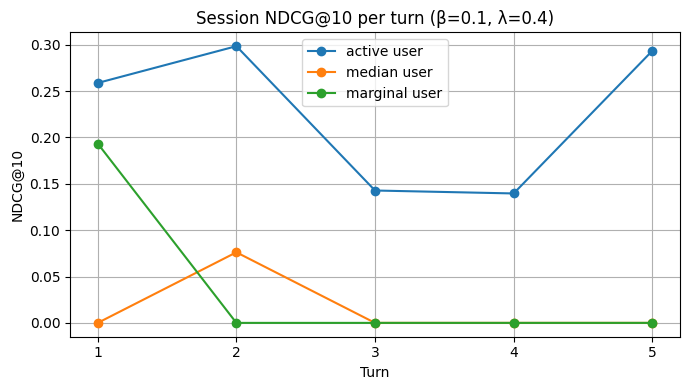

In [55]:
# Plot NDCG@10 per turn for all 3 sessions
fig, ax = plt.subplots(figsize=(7, 4))
for label, ndcg_list in session_ndcg.items():
    ax.plot(range(1, N_TURNS + 1), ndcg_list, marker='o', label=f'{label} user')
ax.set_xlabel('Turn')
ax.set_ylabel('NDCG@10')
ax.set_title(f'Session NDCG@10 per turn (β={EMA_BETA}, λ={MMR_ALPHA})')
ax.set_xticks(range(1, N_TURNS + 1))
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()